# Data Integrity and Volume Audit


This notebook performs a comprehensive audit of the data pipeline. It tracks the volume and integrity of the datasets across four key stages:

1. Broad Harvesting: Initial extraction of COVID-19 related news from GDELT.

2. Strict Filtering: Isolation of articles specifically addressing Mental Health using a refined keyword strategy.

3. Vectorization: Extraction of contextual embeddings (occurrences) from the filtered corpus.

4. Subspace Modeling: Final results derived from matrix decomposition.

The goal is to ensure consistency, identify any data loss, and validate the uniqueness of articles (URLs) across the temporal windows.

## 1. Imports and Configuration

In [3]:
import pandas as pd
import numpy as np
import os

# Define paths
PATHS = {
    "broad": r"../data/raw/harvest/_merged/spain_covid_broad_ALL.csv",
    "strict": r"../data/interim/datasets/spain_covidMHstrict_2020-03_2021-03_ALL.csv",
    "embeddings": r"../data/interim/embeddings/spain_covidMHstrict_occurrences_2020-03_2021-03_CLEANED.csv",
    "results": r"../data/phase3_results.parquet"
}

# Set display options
pd.options.display.float_format = '{:,.2f}'.format

## 2. Comprehensive Data Audit Script

In [4]:
def run_audit():
    print("🔍 STARTING DATA INTEGRITY AUDIT...\n")
    summary = []

    # --- PHASE 1: BROAD COVID CORPUS ---
    if os.path.exists(PATHS["broad"]):
        df_broad = pd.read_csv(PATHS["broad"], usecols=['url'])
        total_broad = len(df_broad)
        unique_broad = df_broad['url'].nunique()
        summary.append(["Phase 1: Broad COVID", total_broad, unique_broad])
        print(f"✅ Phase 1 Loaded: {total_broad:,} rows found.")
    else:
        print(f"❌ Broad file not found at: {PATHS['broad']}")

    # --- PHASE 1: STRICT MH FILTERED ---
    if os.path.exists(PATHS["strict"]):
        df_strict = pd.read_csv(PATHS["strict"], usecols=['url'])
        total_strict = len(df_strict)
        unique_strict = df_strict['url'].nunique()
        summary.append(["Phase 1: Strict MH", total_strict, unique_strict])
        print(f"✅ Phase 1 (Strict) Loaded: {total_strict:,} rows found.")
    else:
        print(f"❌ Strict file not found at: {PATHS['strict']}")

    # --- PHASE 2: EMBEDDINGS (OCCURRENCES) ---
    if os.path.exists(PATHS["embeddings"]):
        # Embeddings usually don't have URL, just count the rows (occurrences)
        df_emb = pd.read_csv(PATHS["embeddings"])
        total_emb = len(df_emb)
        summary.append(["Phase 2: Embeddings", total_emb, "N/A (Occurrences)"])
        print(f"✅ Phase 2 (Embeddings) Loaded: {total_emb:,} occurrences found.")
    else:
        print(f"❌ Embeddings file not found.")

    # --- PHASE 3: SUBSPACE RESULTS ---
    if os.path.exists(PATHS["results"]):
        df_res = pd.read_parquet(PATHS["results"])
        total_res_windows = len(df_res)
        summary.append(["Phase 3: Subspace Windows", total_res_windows, "N/A"])
        print(f"✅ Phase 3 (Results) Loaded: {total_res_windows} windows analyzed.")
    else:
        print(f"❌ Phase 3 results not found.")

    # Create Summary DataFrame
    audit_df = pd.DataFrame(summary, columns=["Phase", "Total Rows/Lines", "Unique Articles (URLs)"])
    
    print("\n" + "="*50)
    print("FINAL DATA FUNNEL SUMMARY")
    print("="*50)
    display(audit_df)
    
    # Calculate Ratios
    if len(summary) >= 2:
        retention = (summary[1][1] / summary[0][1]) * 100
        print(f"\n💡 Mental Health articles represent {retention:.2f}% of total COVID news.")
        
    if len(summary) >= 3:
        density = (summary[2][1] / summary[1][1])
        print(f"💡 On average, we extracted {density:.2f} occurrences (embeddings) per MH article.")

run_audit()

🔍 STARTING DATA INTEGRITY AUDIT...

✅ Phase 1 Loaded: 53,055 rows found.
✅ Phase 1 (Strict) Loaded: 2,156 rows found.
✅ Phase 2 (Embeddings) Loaded: 7,535 occurrences found.
✅ Phase 3 (Results) Loaded: 11 windows analyzed.

FINAL DATA FUNNEL SUMMARY


,Phase,Total Rows/Lines,Unique Articles (URLs)
0,Phase 1: Broad COVID,53055,53055
1,Phase 1: Strict MH,2156,2156
2,Phase 2: Embeddings,7535,N/A (Occurrences)
3,Phase 3: Subspace Windows,11,N/A



💡 Mental Health articles represent 4.06% of total COVID news.
💡 On average, we extracted 3.49 occurrences (embeddings) per MH article.


---

In [6]:
F_PATH = r"../data/interim/datasets/spain_covidMHstrict_2020-03_2021-03_ALL.csv"

In [20]:
# Carga el dataset de la Fase 1 (el filtrado de salud mental)
df_mh = pd.read_csv(F_PATH)

# 1. Comprobar si hay duplicados por URL (si tienes esa columna)
if 'url' in df_mh.columns:
    unique_articles = df_mh['url'].nunique()
    print(f"Total de líneas: {len(df_mh)}")
    print(f"Artículos únicos (por URL): {unique_articles}")
elif 'title' in df_mh.columns:
    unique_articles = df_mh['title'].nunique()
    print(f"Total de líneas: {len(df_mh)}")
    print(f"Artículos únicos (por Título): {unique_articles}")

# 2. Ver un ejemplo
print("\nPrimeras 5 líneas para ver la estructura:")
display(df_mh.head(5))

Total de líneas: 2156
Artículos únicos (por URL): 2156

Primeras 5 líneas para ver la estructura:


,title,newspaper,url,published_at,plain_text,keyword,relevance_score,source,mh_matches,covid_matches
0,Botón de pausa,eldiario.es,https://www.eldiario.es/canariasahora/canarias...,2020-03-04 23:15:00+00:00,Hace unos días The New York Times promocionaba...,"covid, coronavirus, pandemia",30.00,GDELT,salud mental,coronavirus
1,Coronavirus y niños : ¿ Qué contar y cómo ?,eldiario.es,https://www.eldiario.es/nidos/Coronavirus-nino...,2020-03-07 22:45:00+00:00,Coronavirus y niños: ¿Qué contar y cómo?\n\nEs...,"covid, coronavirus, pandemia",100.00,GDELT,psicologo;psicólogo,covid;covid-19;coronavirus
2,Voces femeninas : desde la China más profunda,lavanguardia.com,https://www.lavanguardia.com/cultura/culturas/...,2020-03-08 07:00:00+00:00,Ha querido la casualidad que en medio de la cr...,"covid, coronavirus, pandemia",40.00,GDELT,suicidio,coronavirus
3,Mujeres a pie de calle contras las violencias ...,lavanguardia.com,https://www.lavanguardia.com/vida/20200308/474...,2020-03-08 10:30:00+00:00,La doctora Lluïsa Garcia-Esteve lleva un lazo ...,"covid, coronavirus, pandemia",10.00,GDELT,salud mental;psiquiatra,coronavirus
4,Coronafobia,20minutos.es,https://www.20minutos.es/opinion/inaki-ortega-...,2020-03-09 06:30:00+00:00,Me cuentan mis hijos que una serpiente se dio ...,"covid, coronavirus, pandemia",30.00,GDELT,psiquiatria;psiquiatría,covid;covid-19;coronavirus;pandemia


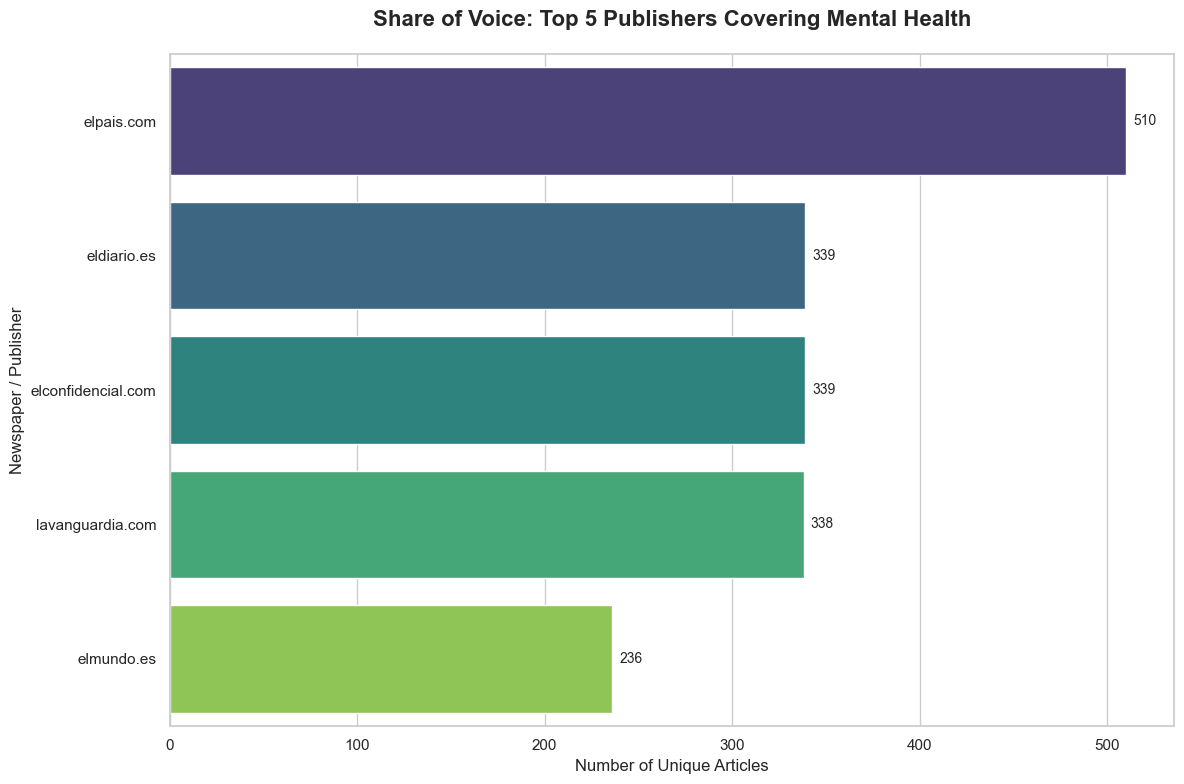

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
df = pd.read_csv('../data/interim/datasets/spain_covidMHstrict_2020-03_2021-03_ALL.csv')

# 2. Setup visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# 3. Calculate top publishers
top_n = 5
publisher_counts = df['newspaper'].value_counts().head(top_n)

# 4. Create the plot
plt.figure(figsize=(12, 8))
ax = sns.barplot(x=publisher_counts.values, y=publisher_counts.index, palette="viridis", hue=publisher_counts.index ,legend=False)

# Add data labels
for p in ax.patches:
    ax.annotate(f'{int(p.get_width())}', 
                (p.get_width(), p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=10)

plt.title('Share of Voice: Top 5 Publishers Covering Mental Health', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Number of Unique Articles', fontsize=12)
plt.ylabel('Newspaper / Publisher', fontsize=12)
plt.tight_layout()
plt.show()

C:\Users\alvar\AppData\Local\Temp\ipykernel_29180\2417610069.py:7: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['month_year'] = df['published_at'].dt.to_period('M').astype(str)


<Figure size 1400x700 with 0 Axes>

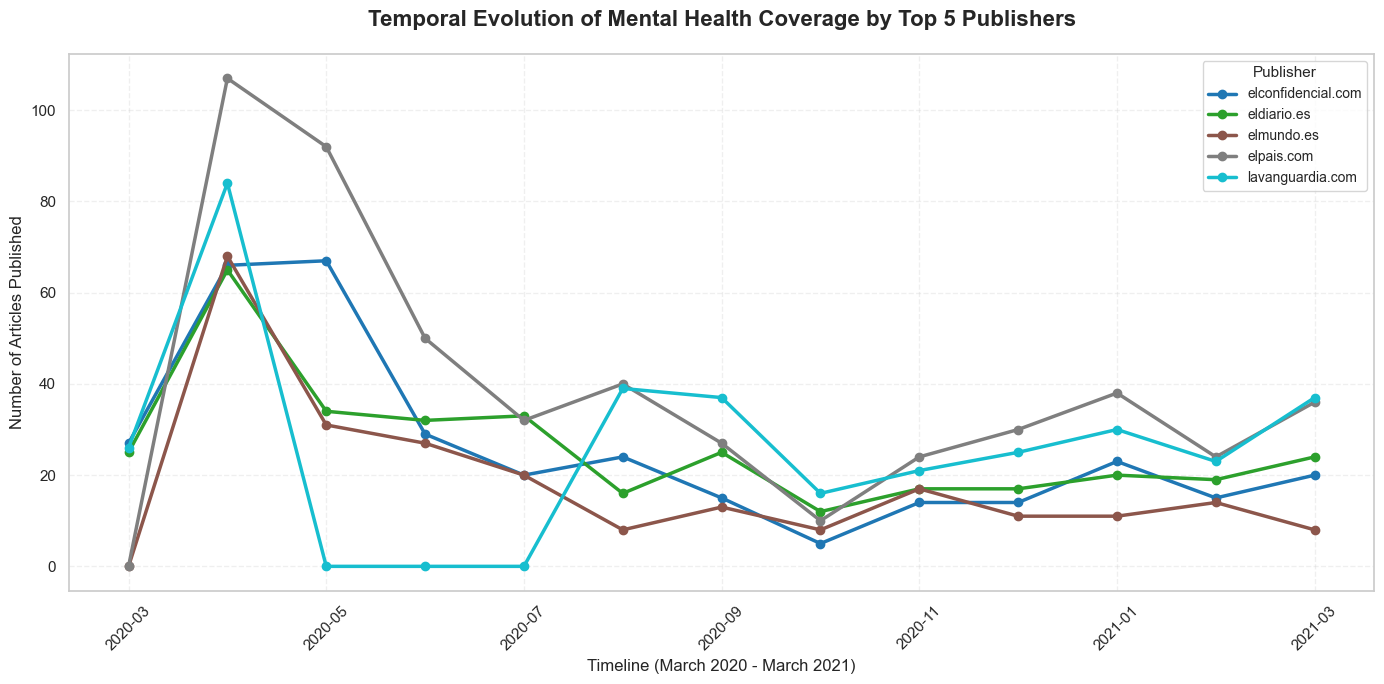

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Convert dates and extract month
df['published_at'] = pd.to_datetime(df['published_at'])
df['month_year'] = df['published_at'].dt.to_period('M').astype(str)

# 2. Get the Top 5 publishers
top_5_publishers = df['newspaper'].value_counts().head(5).index
df_top5 = df[df['newspaper'].isin(top_5_publishers)]

# 3. Group by month and publisher
monthly_publisher = df_top5.groupby(['month_year', 'newspaper']).size().unstack(fill_value=0)

# 4. Create a stacked area chart or line chart
plt.figure(figsize=(14, 7))
monthly_publisher.plot(kind='line', marker='o', linewidth=2.5, figsize=(14, 7), cmap='tab10')

plt.title('Temporal Evolution of Mental Health Coverage by Top 5 Publishers', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Timeline (March 2020 - March 2021)', fontsize=12)
plt.ylabel('Number of Articles Published', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Publisher', title_fontsize='11', fontsize='10')
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

**Media Representation and Publisher Dynamics**

To contextualize the corpus beyond pure temporal and lexical metrics, an analysis of the publishing sources was conducted. The application of strict mental health filters consolidated the dataset around 9 primary national news publishers, totaling 2,156 unique articles. This concentration provides a robust sample of mainstream media discourse, allowing for a comparative analysis of how different editorial agendas engaged with the topic.

**1. Share of Voice: A Mainstream Consensus**
The Share of Voice (SoV) (Figure 1) distribution reveals that mental health coverage was driven by a powerful mix of legacy media and digital-native platforms. The historical legacy newspaper El País leads the overall volume by a significant margin with 510 unique articles. However, the most striking finding is the near-perfect statistical tie for the second position among three major outlets with entirely distinct formats and editorial lines: the progressive digital-native eldiario.es (339), the independent digital El Confidencial (339), and the traditional Catalan legacy paper La Vanguardia (338). They are closely followed by El Mundo (236).

Key Takeaways (Figure 1):
- Transversal and Universal Priority: The identical volume produced by eldiario.es, El Confidencial, and La Vanguardia proves that mental health was a universal editorial priority. It was not monopolized by a single ideological faction or a specific media format (digital vs. print-origin).
- The "Top 5" Influence: The five leading publishers account for over 80% of the entire corpus (1,762 out of 2,156 articles). It is crucial to recognize that the overall semantic structure of "mental health" is fundamentally shaped by the consensus of these five dominant outlets.

**2. Temporal Evolution: Synchronized Peaks among the Top 5**
The longitudinal tracking of the Top 5 publishers (El País, eldiario.es, El Confidencial, La Vanguardia, El Mundo) demonstrates how the primary agenda-setters reacted to pandemic milestones.

Key Takeaways (Figure 2):
- The "March Shock": All five publishers exhibit a sharp, simultaneous spike at the onset of the National Lockdown (March-April 2020). This confirms that the initial framing of mental health was a universal, reactive media phenomenon driven by the immediate psychological trauma of confinement.
- Sustained vs. Reactive Strategies: After the initial wave, editorial strategies diverged. While all top publishers reacted again during the "Second Wave" (October 2020), their baselines varied. The temporal tracking highlights whether certain outlets maintained mental health as a structural, daily topic or treated it strictly as a crisis-driven subject that spiked only during government-mandated lockdowns.
- Alligns with eda plot of news article volume agains main milestones
- Volume of 0 for La vanguardia occurs due to a testing 2 month period. La vanguardia introduced a lot of inestability, issues and challenges during data harvesting. It was removed for testing and later incorporated. 

---

C:\Users\alvar\AppData\Local\Temp\ipykernel_29180\3170143544.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='relevance_score', y='newspaper', data=df_top10,


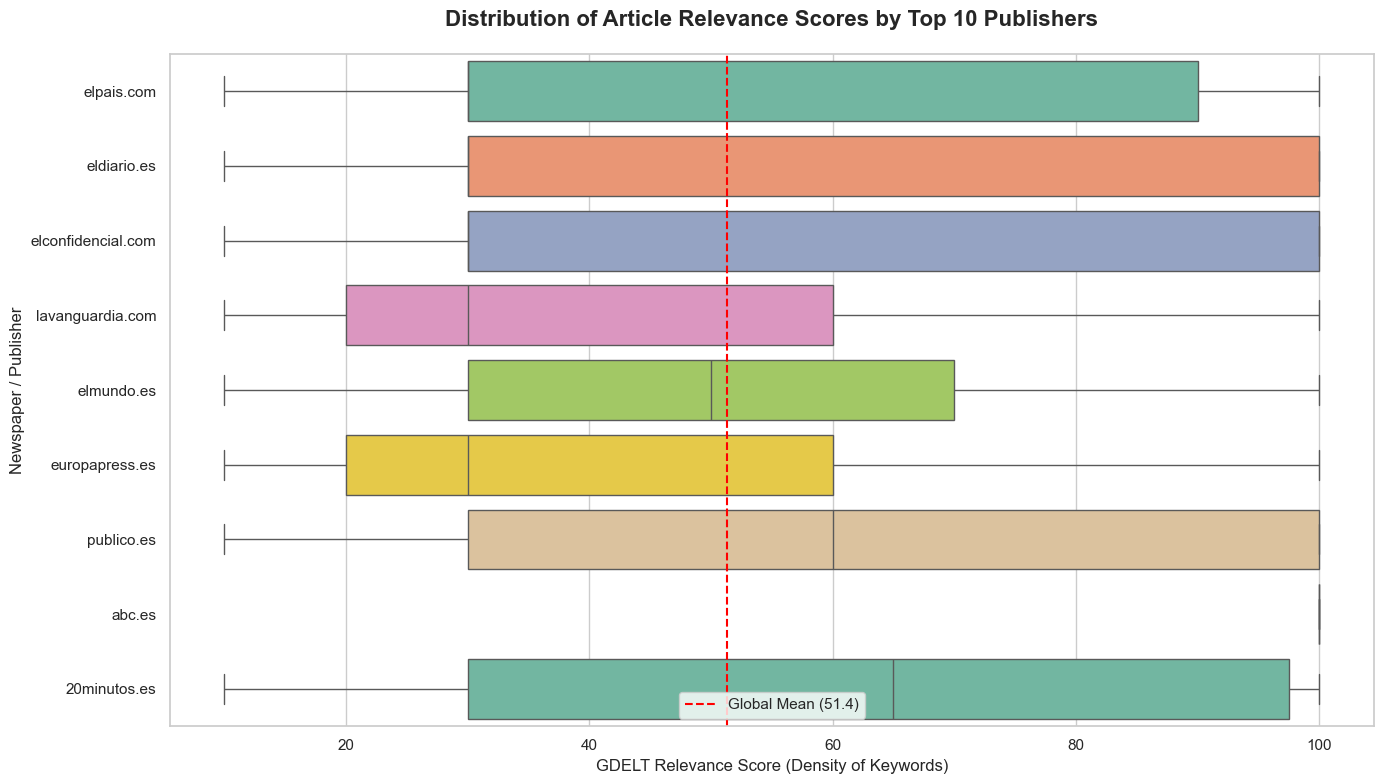

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filter for the Top 10 publishers to keep the chart clean
top_10_publishers = df['newspaper'].value_counts().head(10).index
df_top10 = df[df['newspaper'].isin(top_10_publishers)]

# 2. Create the Boxplot
plt.figure(figsize=(14, 8))
sns.boxplot(x='relevance_score', y='newspaper', data=df_top10, 
            order=top_10_publishers, palette='Set2', showfliers=False) # showfliers=False hides extreme outliers for clarity

# Add a vertical line for the global average
global_mean = df['relevance_score'].mean()
plt.axvline(global_mean, color='red', linestyle='--', label=f'Global Mean ({global_mean:.1f})')

plt.title('Distribution of Article Relevance Scores by Top 10 Publishers', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('GDELT Relevance Score (Density of Keywords)', fontsize=12)
plt.ylabel('Newspaper / Publisher', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()